In [1]:
# Script for NC apical area ROC analysis shown in Figure S2

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('CombinedMatrixPreWindowFirstSignFrameFINAL0925.csv')
df = df.dropna(subset=['area', 'contact_length', 'contact_duration', 'signalling'])

df = df[df['contact_duration'] >= 0]

areas_signal = df.loc[df['signalling'] == 1, 'area']

# Areas of non-signalling cells
areas_no_signal = df.loc[df['signalling'] == 0, 'area']

In [3]:
# Combine into one array
areas = np.array(list(areas_signal) + list(areas_no_signal))
labels = np.array([1] * len(areas_signal) + [0] * len(areas_no_signal))

In [4]:
# Compute ROC
fpr, tpr, thresholds = roc_curve(labels, areas)
roc_auc = auc(fpr, tpr)

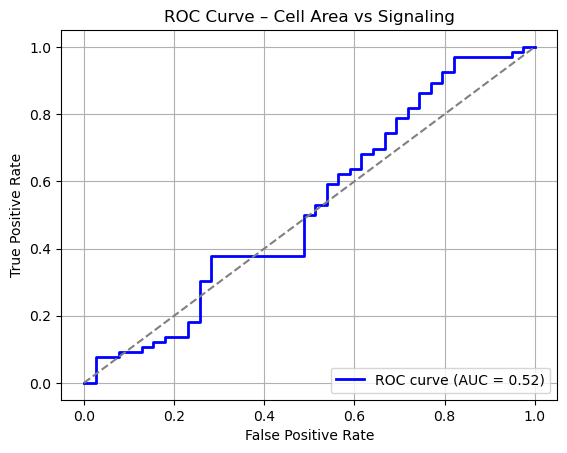

In [5]:
# Plot
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Cell Area vs Signaling')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('ROC Area vs Signalling.pdf')
plt.show()

In [6]:
# AUC = 0.5: no better than chance — area has no predictive value
# AUC > 0.7: decent predictive value
# AUC > 0.9: strong predictor

In [7]:
# Youden's J for all thresholds
youden_j = tpr - fpr

# Index of the max J
j_idx = np.argmax(youden_j)

# Optimal threshold
optimal_threshold = thresholds[j_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"TPR: {tpr[j_idx]:.2f}, FPR: {fpr[j_idx]:.2f}, Youden's J: {youden_j[j_idx]:.2f}")

Optimal threshold: 35.47
TPR: 0.97, FPR: 0.82, Youden's J: 0.15
